# CLIPS Constructs

Refer the details in lecture notes 7.

# Section A: Conflict Resolution

* Set the **conflict resolution** strategies: 
 * **FCFS**: (set-strategy breadth) 
 * **Specificity**: (set-strategy lex) 
 * **Recency**: (set-strategy depth) 
 * **Highest Priority**: default (set-strategy lex), use salience

1. Refer to the Lab 4, question 3 - Create the conflict resolution based on **ordered fact**.

In [1]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# env.build("""(deffacts init
#                 (engine wont_start)
#                 (sound clicking_noise))""")

env.build("""(defrule R1
               (engine wont_start)
             =>
             (printout t "battery may be weak!" crlf))""")

env.build("""(defrule R2
               (engine wont_start)
               (sound silence)
             =>
             (printout t "starter is faulty!" crlf))""")

env.build("""(defrule R3
                (engine wont_start)
                (sound clicking_noise)
             =>
            (printout t "battery may be dead!" crlf))""")

env.reset()

# Debug
# env.eval("(watch rules)") #(watch facts), ...

# Method 1: Set the conflict resolution strategy
#env.strategy = clips.Strategy.BREADTH  
#env.strategy = clips.Strategy.DEPTH    
#env.strategy = clips.Strategy.LEX      

# Method 2: Set the conflict resolution strategy
#env.eval("(set-strategy breadth)")
#env.eval("(set-strategy depth)")
#env.eval("(set-strategy lex)")

# Scenario 1
env.eval("(assert (engine wont_start)(sound clicking_noise))")

# Scenario 2
# env.eval("(assert (sound clicking_noise))")
# env.eval("(assert (engine wont_start))")
  
#env.eval("(agenda)")

env.run()


ModuleNotFoundError: No module named 'clips'

2. Based on highest priority based on user's salience

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# env.build("""(deffacts init
#                 (engine wont_start)
#                 (sound clicking_noise))""")

env.build("""(defrule R1
               (declare (salience 50))
               (engine wont_start)
             =>
             (printout t "battery may be weak!" crlf))""")

env.build("""(defrule R2
               (engine wont_start)
               (sound silence)
             =>
             (printout t "starter is faulty!" crlf))""")

env.build("""(defrule R3
                (declare (salience 30))
                (engine wont_start)
                (sound clicking_noise)
             =>
            (printout t "battery may be dead!" crlf))""")

env.reset()

# Debug
# env.eval("(watch rules)") #(watch facts), ...

env.eval("(set-strategy lex)")

# Scenario 1
env.eval("(assert (engine wont_start)(sound clicking_noise))")

# Scenario 2
# env.eval("(assert (sound clicking_noise))")
# env.eval("(assert (engine wont_start))")
  
#env.eval("(agenda)")

env.run()


3. Refer to the same question - Create the conflict resolution based on **unordered fact**.

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate car
               (slot engine)
               (slot sound))""")

env.build("""(defrule R1
               (car (engine wont_start))
             =>
             (printout t "battery may be weak!" crlf))""")

env.build("""(defrule R2
               (car (engine wont_start)
                    (sound silence))
             =>
             (printout t "starter is faulty!" crlf))""")

env.build("""(defrule R3
               (car (engine wont_start)
                    (sound clicking_noise))
             =>
            (printout t "battery may be dead!" crlf))""")

env.reset()

# Debug
# env.eval("(watch rules)") #(watch facts), ...

#env.eval("(set-strategy breadth)")
#env.eval("(set-strategy depth)")
#env.eval("(set-strategy lex)")

# Scenario 3
env.eval("(assert (car (engine wont_start)(sound clicking_noise)))")

# Scenario 4
# env.eval("(assert (car (sound clicking_noise)))")
# env.eval("(assert (car (engine wont_start)))")
  
#env.eval("(agenda)")

env.run()

* **Questions:** <br>
  1. **FCFS**: Explain why both assertions (car (engine wont_start)(sound clicking_noise)) or (car (sound clicking_noise)(engine wont_start)) the output still R1 -> R3? <br>
  2. **Recency**: Explain why changing from (car (engine wont_start)(sound clicking_noise)) to (car (sound clicking_noise)(engine wont_start)) the output still R3 -> R1? <br>
  3. Why the result for scenario 3 and scenario 4 are different? <br> (**Hints**) **ordered fact** vs **unordered fact**

# Section B: Backward Chaining 

In **CLIPS**, **default inference** is using **forward chaining** technique. Example **backward chaining** technique below is just a basic implementation. For complete backward chaining, the implementation must consider for the **conflict resolution** as well.

In [ ]:
import clips

# Initialize CLIPS environment
env = clips.Environment()

# Initialize facts
env.build("""(deffacts init (ingredient flour)
                          (ingredient eggs)
                          (ingredient sugar)
                          (have-time yes))""")

# Define CLIPS rules and facts
env.build("""(defrule rule1
               (ingredient flour)
               (ingredient eggs)
               (ingredient sugar)
             => (assert (action bake-cake)))""")

env.build("""(defrule rule2
                (or (not (ingredient flour))
                (not (ingredient eggs))
                (not (ingredient sugar)))
             => (assert (action buy-cake)))""")

env.build("""(defrule rule3
                (have-time yes)
             => (assert (result bake-cake)))""")


env.reset()

#Backward chaining function
def backward_chain(goal):
    
    # Check the goal before running inference
    for fact in env.facts():
        if str(fact) == goal:
            return True

    # Before inference
    initial_facts = len(list(env.facts())) #return 4
    
    # After inference
    env.run()  
    final_facts = len(list(env.facts())) # return 6

    # Check the goal after running inference
    for fact in env.facts():
        if str(fact) == goal:
            return True

    if initial_facts == final_facts:
        return False

    # Recursive function
    return backward_chain(goal)

# Goal to achieve
goal = "(result bake-cake)"

# Perform backward chaining
if backward_chain(goal):
    print(f"Goal achieved: {goal}")
else:
    print(f"Goal could not be achieved: {goal}")

#Print final facts
print("\nFinal Facts in the Knowledge Base:")
for fact in env.facts():
    print(fact)


# Section C: Semantic-based Expert System

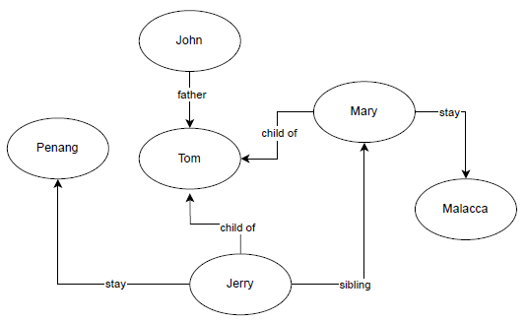

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts family (father John Tom)
                              (child Mary Tom)
                              (child Jerry Tom)
                              (stay Mary Malacca)
                              (sibling Jerry Mary)
                              (stay Jerry Penang))""")

env.build("""(defrule who-is-the-sibling-of-Jerry
                    (sibling Jerry ?sis)
                     => (printout t "Jerry's sibling is " ?sis crlf))""")


env.build("""(defrule where-does-Jerry-stay 
                    (stay Jerry ?place)
                     =>(printout t "Jerry stays at " ?place crlf))""")

env.reset()

# inference
env.run()


# Section D: Knowledge-Based Expert System

* Diagram below is a **frame-based knowledge representation**. Create **CLIPS contructs** for **classes** and build **inheritance (is-a)** and **instance** relationships. As well as **has-a (aggregation)** and **has-a (composition)** relationships. The **reasoning** here is to locate the instance of garfield and snoopy. The **challenges of user interface** are **users' inputs are varies**, choose the facts from words and **match** with predefined facts in a Expert System is important. Additional to this, **auto word correction** and **lower case the words** could make further accurate results. Therefore, this example is enhanced with **natural language processing (NLP)** to overcome the challenges. Furthermore, the **text-to-speech** could make the Expert System more **interactive experience**.

In [ ]:
#pip install pyttsx3

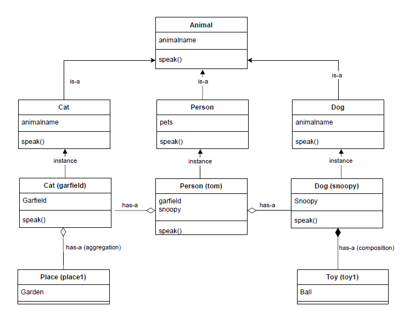

1. Create frames with **is-a** relationship

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(defclass Animal (is-a USER)
                (slot animalname))""")

env.build("""(defclass Dog (is-a Animal)
               (slot animalname)
               (slot has-toy))""")

env.build("""(defclass Cat (is-a Animal)
               (slot animalname)
               (slot place))""")

env.build("""(defclass Toy (is-a USER)
               (slot toyname))""")

env.build("""(defclass Place (is-a USER)
               (slot placename))""")

env.build("""(defclass Person (is-a USER)
               (multislot pets))""")
   

2. Attach **function(s)** to a class

In [ ]:
env.build("""(defmessage-handler Animal speak ()
               (printout t "Animal make sound ..." crlf))""")

env.build("""(defmessage-handler Dog speak ()
               (assert (animal "Bark bark ...")))""")

env.build("""(defmessage-handler Cat speak ()
               (assert (animal "Meow meow ...")))""")

2. Create an **instance** with **has-a (composition)** relationship

In [ ]:
env.eval("""(make-instance snoopy of Dog (animalname Snoopy)
                                       (has-toy (make-instance toy1 of Toy (toyname Ball))))""")

3. Create an **instance** with **has-a(aggregation)** relationship

In [ ]:
env.eval("""(make-instance place1 of Place (placename Garden))""")

env.eval("""(make-instance garfield of Cat (animalname Garfield)
                                       (place place1))""")

4. Create an **instance** with **has-a(aggregation)** relationship with **more than one instances**

In [ ]:
env.eval("""(make-instance tom of Person (pets (create$ snoopy garfield)))""")

5. Adjust your speaker accordingly to experience the **text to speech**.

In [ ]:
import pyttsx3

engine = pyttsx3.init()

engine.setProperty('rate',200)

# Example input = garfield
# Example input = snoopy
user_input=input("Enter your favourite animal to speak with you.")

#env.eval("(find-all-instances ((?ins USER)) TRUE)")

try:
    env.eval("(bind ?output (find-instance ((?ins USER)) (eq [" + user_input + "] ?ins)))")
    env.eval("""(do-for-all-facts ((?f animal)) (retract ?f))""")
    env.eval("""(send (nth$ 1 ?output) speak)""")
    engine.say(list(env.facts())[0][0])
    engine.runAndWait()
    
except Exception as e:
    engine.say("Sorry, cannot find!")
    engine.runAndWait()


6. Enhance user interface through **Natural Language Processing (NLP)**

In [ ]:
#pip install pyspellchecker
#nltk.download('punkt_tab')
#nltk.download('punkt')
#nltk.download('wordnet')
#nltk.download('stopwords')
#nltk.download('averaged_perceptron_tagger')
#nltk.download('averaged_perceptron_tagger_eng')
#nltk.download('omw-1.4')

In [ ]:
import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from spellchecker import SpellChecker
from clips import Environment

# Function to enhance input
def corrected_input(user_input):
    
    spell = SpellChecker()
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words("english"))

    # Tokenize input
    tokens = word_tokenize(user_input)
    
    # POS tagging
    tagged_words =pos_tag(tokens)

    corrected_words = []
    for word,tag in tagged_words:
         # Skip stop words
        if word.lower() not in stop_words:
            # Filtered words for (proper noun, singular), (common noun, singular, plural)
            if tag in ['NNP','NN','NNS']: 
                if tag in ['NN','NNS']: # Only correct (common noun, singular, plural) in the dictionary
                    corrected = spell.correction(word) if word.lower() not in spell and word.isalpha() else word
                else: # Garfield & Snoopy
                    corrected = word
                
                # Lemmatize the corrected word
                lemma = lemmatizer.lemmatize(corrected)
                corrected_words.append(lemma)

    return " ".join(corrected_words)


In [ ]:
import pyttsx3

engine = pyttsx3.init()

engine.setProperty('rate',200)

# Example input = I love Garfield
# Example input = I love Snoopy
user_input=input("Enter your favourite animal to speak with you.")
filtered_user_input = corrected_input(user_input).lower()
print(filtered_user_input)

try:
    env.eval("(bind ?output (find-instance ((?ins USER)) (eq [" + filtered_user_input + "] ?ins)))")
    env.eval("""(do-for-all-facts ((?f animal)) (retract ?f))""")
    env.eval("(send (nth$ 1 ?output) speak)")
    engine.say(list(env.facts())[0][0])
    engine.runAndWait()
    
except Exception as e:
    engine.say("Sorry, cannot find! Please provide additional context.")
    engine.runAndWait()   


# Section D: Car Troubleshooting Expert System Through Case-based Reasoning

4R - **R**epresenting, **R**etrieve, **R**euse and **R**etain

1. Create the facts below to the case_library.txt and save into the same folder with the Lab 7.ipynb <br>
(car-troubleshooting (can-start yes) (engine-noise 200) (solution replace-belt)) <br>
(car-troubleshooting (can-start yes) (engine-noise 80) (solution check-battery)) <br>
(car-troubleshooting (can-start no) (engine-noise 0) (solution check-fuel))

In [ ]:
import clips 
import logging
from datetime import datetime

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# Representing a case
env.build("""(deftemplate car-troubleshooting
                   (slot can-start)
                   (slot engine-noise)
                   (slot solution))""")

env.build("""(deftemplate car-query
                   (slot can-start)
                   (slot engine-noise))""")

env.build("""(deftemplate similarity
                   (slot solution)
                   (slot score))""")


# Load case library
# env.build("""(deffacts case (car-troubleshooting (can-start yes) (engine-noise 200) (solution replace-belt))
#                             (car-troubleshooting (can-start yes) (engine-noise 80) (solution check-battery))
#                             (car-troubleshooting (can-start no) (engine-noise 0) (solution check-fuel)))""")

fact=""
with open('case_library.txt', 'r') as file:
    for line in file:
        fact=fact+line.strip()
    env.build("""(deffacts case """+fact+""")""")
        
# Retrieve similar case
env.build("""(defrule calculate-similarity
                 ?query <- (car-query (can-start ?query-start) (engine-noise ?query-noise))
                 ?case <- (car-troubleshooting (can-start ?case-start) (engine-noise ?case-noise) (solution ?case-solution))
              =>  (bind ?score 0)
                  (if (eq ?query-start ?case-start) then (bind ?score (+ ?score 1)))                ;;+1 if can-start is match
                  (bind ?noise-diff (abs (- ?query-noise ?case-noise)))                             ;;similarity of engine-noise
                  (if (<= ?noise-diff 50) then (bind ?score (+ ?score (- 1 (/ ?noise-diff 50.0))))) ;;tolerance +/-50
                  (assert (similarity (solution ?case-solution) (score ?score))))""")

env.build("""(defrule retrieve-most-similar
                  (similarity (solution ?case-solution) (score ?score))
             =>(printout t "Most similar case: " ?case-solution " with similarity score: " ?score crlf))""")

env.build("(defglobal ?*max-solution* = nil)")
env.build("(defglobal ?*max-score* = -1)")
env.build("""(defrule find-max-score
               (similarity (solution ?solution) (score ?score))
               (test (> ?score ?*max-score*))
              =>(bind ?*max-score* ?score)
                (bind ?*max-solution* ?solution))""")

env.eval("(ppdeffacts case)")

2. Reuse and retain the solution. Check the new solution has been added to the case_library.txt.

In [ ]:
env.reset()
query="(car-query (can-start yes) (engine-noise 100))" # remove hash tag for reuse solution
env.eval("(assert " +query+")")
env.run()

# Reuse the solution
env.build("""(defrule reuse-solution-retain
                    (test (> 1.8 ?*max-score*))
              => (printout t "Suggested solution:" ?*max-solution* " with similarity score:" ?*max-score* crlf))""")

env.run()

# Retain
#print("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))")
with open('case_library.txt', 'a') as file:
    file.writelines("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))\n")
    

3. Revise and retain as no solution. Check the facts without solution has been added to the case_library.txt.

In [ ]:
env.eval("(undefrule reuse-solution-retain)")

env.reset()
query="(car-query (can-start no) (engine-noise 150))"   # remove hash tag for revise solution

env.eval("(assert " +query+")")
env.run()

# Revise the solution
env.build("""(defrule revise-solution-retain
                    (test (< 0.5 ?*max-score*))
              => (bind ?*max-solution* None)
                 (printout t "No solution!" crlf))""")

env.run()

# Retain
#print("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))")
with open('case_library.txt', 'a') as file:
    file.writelines("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))\n")
    

* Manual Handling Unsolved Cases

In [ ]:
import clips 
import logging
from datetime import datetime

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# Representing a case
env.build("""(deftemplate car-troubleshooting
                   (slot can-start)
                   (slot engine-noise)
                   (slot solution))""")

env.build("""(deftemplate car-query
                   (slot can-start)
                   (slot engine-noise))""")

env.build("""(deftemplate similarity
                   (slot solution)
                   (slot score))""")


fact=""
with open('case_library.txt', 'r') as file:
    for line in file:
        fact=fact+line.strip()
    env.build("""(deffacts case """+fact+""")""")
        
# Retrieve all cases without solutions 
env.build("""(defrule store-new-unsolved-case
                    (car-troubleshooting (can-start ?p1)
                                         (engine-noise ?p2)
                                         (solution None))
             => (printout t "New unsolved case stored: can-start " ?p1 "; engine-noise " ?p2 crlf))""")

env.reset()

env.run()

# Domain expert manually update to the knowledge based
# Open the case library and replace the text


## Excercise:

1. Simulate the FuzzyCLIPS (https://sourceforge.net/projects/clipsrules/files/)
